# Non-Uniform Azimuthal Poisson Solver:
# Structured Distorted Angular Grid vs. Uniform FFT with Interpolation

$$
u(r,\theta)
=
(R^2-r^2)
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem is smooth on the full disk, including at
the origin, and satisfies homogeneous Dirichlet boundary conditions:

$$
u(R,\theta)=0.
$$

The angular grid is a structured multi-pole deformation that can represent
periodic angular encoder error, scanner wobble, lens distortion, or a smoothly
distorted polar mesh.

All methods begin with the same distorted angular measurements. Adapted NUFFT
and Adapted NUDFT consume those measurements directly. The Uniform FFT baseline
first applies periodic linear interpolation to place the same measurements on a
uniform angular grid before solving.

In [9]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)



from Tests.paper.helpers import (
    get_single_multipole_problem,
    run_all_algorithms_NxM_study,
    plot_solution_and_grids,
    plot_accuracy_faceted_by_method,
    plot_accuracy_from_df,
    plot_adapted_vs_highres_uniform,
    render_combined_error_table,
    render_combined_runtime_table,
    plot_extreme_runtime_2x2,
)

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [10]:
# ---------------------------------------------------------
# Disk and smooth single-multipole manufactured problem
# ---------------------------------------------------------
R = 1.0
MODE = 16
THETA_0 = np.pi


# ---------------------------------------------------------
# Structured multi-pole angular distortion
#
# theta(xi) = xi + 0.08 sin(2 xi) + 0.04 sin(4 xi)
#
# Monotonicity / distortion measure:
# 0.08 * 2 + 0.04 * 4 = 0.32 < 1.
#
# This is milder than the previous 0.60 distortion measure,
# improving NUFFT CGLS conditioning while retaining realistic
# periodic structured angular distortion.
# ---------------------------------------------------------
GRID_POLES = (2, 4)
GRID_AMPLITUDES = (0.08, 0.04)


# ---------------------------------------------------------
# Solver settings
# ---------------------------------------------------------
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann


# ---------------------------------------------------------
# Resolution study
#
# MODE=16 needs enough angular samples. N=64 is the first
# meaningful resolution in this study.
# ---------------------------------------------------------
N_VALUES = [64, 128, 256]
M_VALUES = [64, 128, 256]


# ---------------------------------------------------------
# Fixed settings for plots
# ---------------------------------------------------------
N_LOW_ADAPT = 64
N_HIGH_UNIFORM = 512
M_FIXED_PLOTS = 128

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

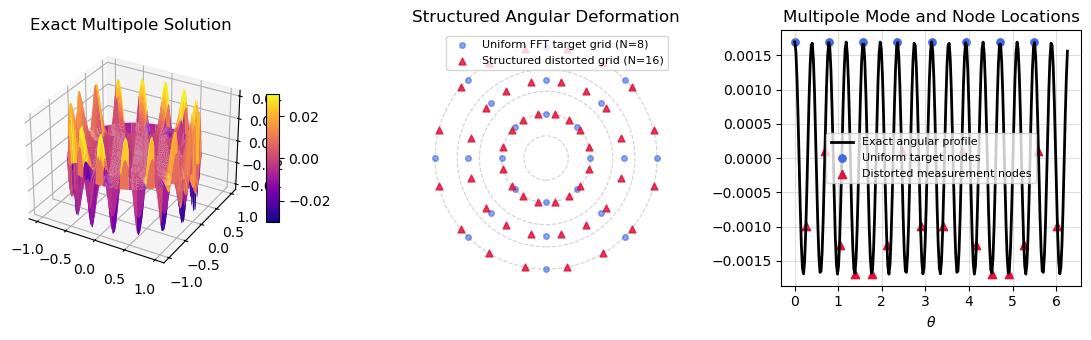

In [11]:
# Construct smooth single-multipole manufactured problem.
problem = get_single_multipole_problem(
    R=R,
    mode=MODE,
    theta_0=THETA_0,
)

# Visualize exact solution, structured distorted measurement grid,
# and Uniform FFT target grid.
plot_solution_and_grids(
    problem=problem,
    N_adapt=16,
    N_unif=8,
    M=M_FIXED_PLOTS,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [12]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
)

Computing N x M multipole-grid study: 100%|██████████| 27/27 [00:41<00:00,  1.53s/it]


## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [13]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")

## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

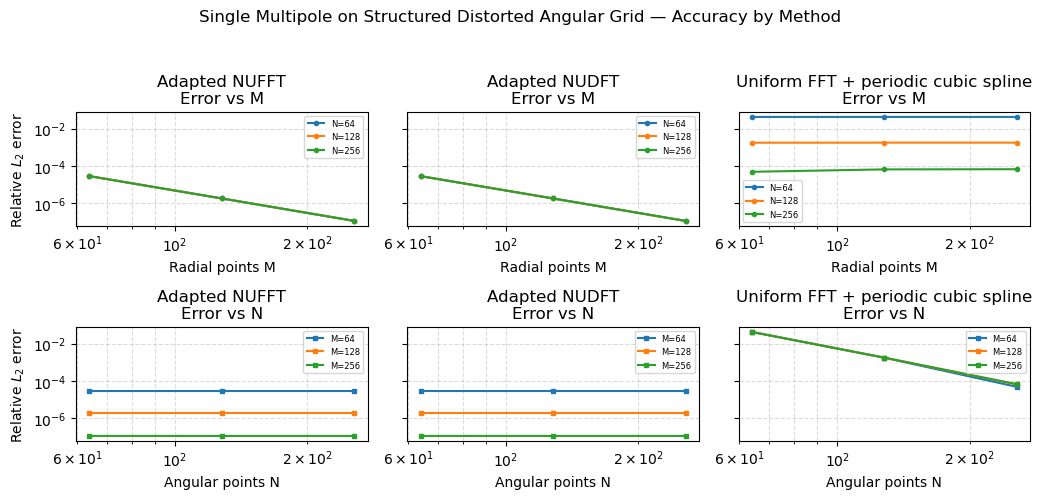

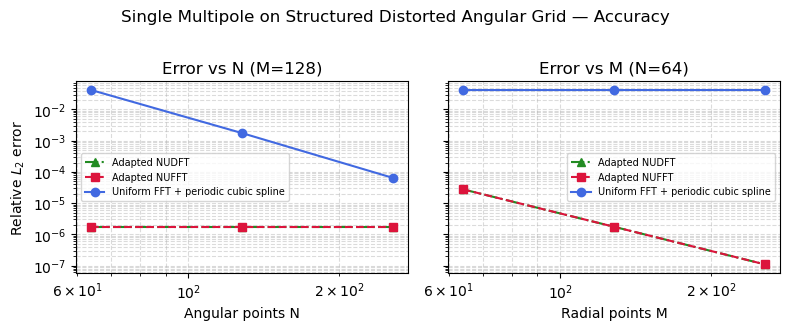

In [14]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).


2 x 2 Disk Error Comparison
                                                 Case   N   M Relative L2 Relative Linf Runtime (s)
                Adapted NUFFT — direct distorted data  64 128   1.748e-06     1.662e-06      1.2747
                Adapted NUDFT — direct distorted data  64 128   1.748e-06     1.662e-06      0.0166
  Uniform FFT + interpolation same measurement budget  64 128   4.191e-02     9.367e-02      0.0051
Uniform FFT + interpolation higher measurement budget 512 128   3.190e-06     5.082e-06      0.0576


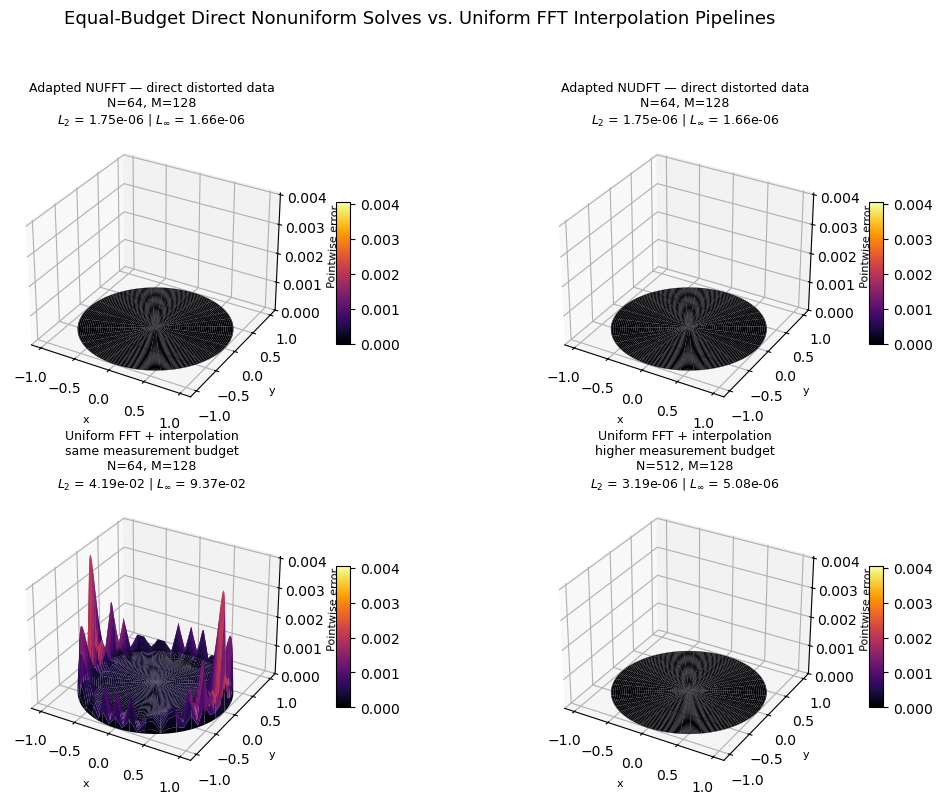

,Case,N,M,Relative L2,Relative Linf,Runtime (s)
0,Adapted NUFFT — direct distorted data,64,128,0.000002,0.000002,1.274745
1,Adapted NUDFT — direct distorted data,64,128,0.000002,0.000002,0.016643
2,Uniform FFT + interpolation same measurement b...,64,128,0.041905,0.093672,0.005106
3,Uniform FFT + interpolation higher measurement...,512,128,0.000003,0.000005,0.057566


In [15]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    poles=GRID_POLES,
    amplitudes=GRID_AMPLITUDES,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE,
)

Runtime Tables ($N$ vs. $M$)


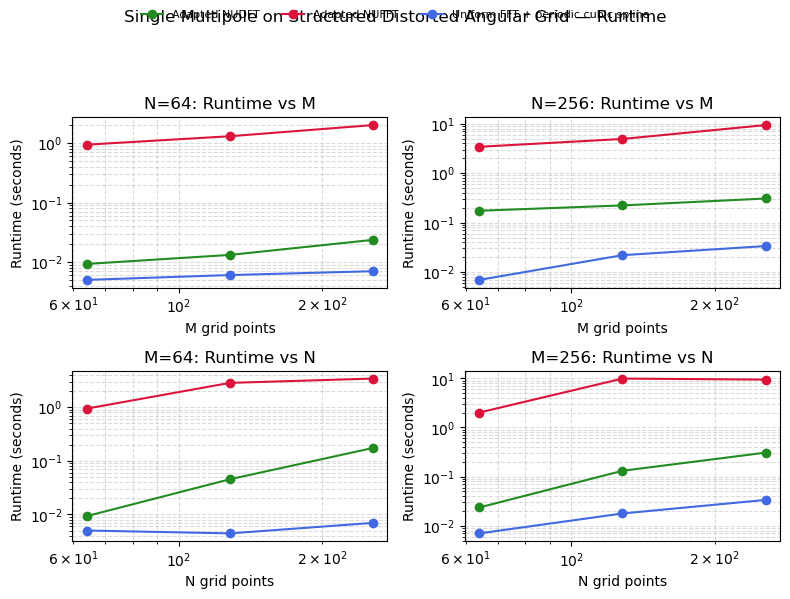

In [16]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results)